# Fluidity Predictability Analysis

Deep-dive analysis of **Fluidity-to-Fluidity** predictability using out-of-sample cross-validation.

## Research Question

Can pre-stimulus **Fluidity** reliably predict post-stimulus **Fluidity** within individual subjects and sessions?

Fluidity (dynamic functional connectivity matrix variance) measures the temporal variability of brain network configurations.

## Methods

For each (subject, session) combination:

1. Extract trials with valid Fluidity data for both pre- and post-stimulus windows
2. Fit OLS regression: `post_fluidity ~ pre_fluidity` on training folds (K=2)
3. Evaluate out-of-sample metrics on held-out test folds:
   - **R²**: Proportion of variance explained
   - **Correlation**: Pearson correlation between predictions and observations
   - **RMSE**: Root mean squared error
4. Compare within-sample vs out-of-sample performance to quantify overfitting
5. Perform permutation test: shuffle pre-stimulus values to assess significance

**Subjects:** N=36 with multiple iEEG recording sessions each
**Spatial window:** radius_pre = radius_post = 100 mm

## Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

In [2]:
# Resolve project root and locate data directory
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'ieeg_metrics'
print(f'Project root: {project_root}')
print(f'Metrics directory: {metrics_root}')

Project root: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main
Metrics directory: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics


## Data Preparation

In [3]:
# Load pre-computed 9-metric dataframe
csv_path_9mois = metrics_root / 'df_9MOIs_ieeg.csv'
df_all = pd.read_csv(csv_path_9mois)

# Filter for:
# 1. Fluidity metric only
# 2. Consistent spatial window (radius_pre and radius_post = 100 mm)
FLUIDITY_METRIC = 'dynamic_functional_connectivity_matrix_var_mat'

df = df_all[
    (df_all['metric_name'] == FLUIDITY_METRIC) & 
    (df_all['radius_pre'] == 100) & 
    (df_all['radius_post'] == 100)
].copy()

print(f'Loaded data shape: {df_all.shape}')
print(f'Fluidity data shape: {df.shape}')
print(f'\nUnique subjects: {df["sub"].nunique()}')
print(f'Unique sessions: {df.groupby("sub")["run_is"].nunique().mean():.1f} sessions per subject on average')
print(f'Total sessions: {df.groupby(["sub", "run_is"]).ngroups}')
print(f'\nData range (trials per session):')
trials_per_session = df.groupby(['sub', 'run_is']).size()
print(f'  Min: {trials_per_session.min()}')
print(f'  Max: {trials_per_session.max()}')
print(f'  Mean: {trials_per_session.mean():.1f}')
print(f'  Median: {trials_per_session.median():.1f}')

Loaded data shape: (3246210, 8)
Fluidity data shape: (10930, 8)

Unique subjects: 36
Unique sessions: 8.8 sessions per subject on average
Total sessions: 318

Data range (trials per session):
  Min: 15
  Max: 60
  Mean: 34.4
  Median: 30.0


## Analysis Functions

In [4]:
def compute_fluidity_cv_detailed(pre_vals, post_vals, n_splits=2, random_state=42):
    """
    Compute detailed cross-validation metrics for Fluidity predictability.
    
    Returns comprehensive performance metrics with error estimates:
    - OOS R² and within-sample R² (for overfitting assessment)
    - OOS/within Pearson correlation and Spearman rank correlation
    - RMSE for both within and OOS
    - Per-fold statistics (std dev of metrics across folds)
    - Model coefficients (slope and intercept)
    
    Parameters
    ----------
    pre_vals : array-like
        Pre-stimulus Fluidity values
    post_vals : array-like
        Post-stimulus Fluidity values
    n_splits : int, default=2
        Number of CV folds
    random_state : int, default=42
        Random seed for reproducibility
    
    Returns
    -------
    dict with keys:
        - n_trials: number of valid trials
        - within_r2: R² on full training data
        - within_corr: Pearson correlation on full data
        - oos_r2: mean out-of-sample R²
        - oos_r2_std: std dev of OOS R² across folds
        - oos_corr: mean out-of-sample Pearson correlation
        - oos_corr_std: std dev of OOS Pearson correlation
        - oos_rmse: mean out-of-sample RMSE
        - oos_rmse_std: std dev of OOS RMSE
        - within_rmse: RMSE on full training data
        - slope: regression slope
        - intercept: regression intercept
        - r_squared_overfitting: (within_r2 - oos_r2) measure of overfitting
    """
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()
    
    # Remove NaN pairs
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    n_trials = len(pre_vals)
    
    # Insufficient data
    if n_trials < n_splits or n_trials < 3:
        return {
            'n_trials': n_trials,
            'within_r2': np.nan,
            'within_corr': np.nan,
            'oos_r2': np.nan,
            'oos_r2_std': np.nan,
            'oos_corr': np.nan,
            'oos_corr_std': np.nan,
            'oos_rmse': np.nan,
            'oos_rmse_std': np.nan,
            'within_rmse': np.nan,
            'slope': np.nan,
            'intercept': np.nan,
            'r_squared_overfitting': np.nan,
        }
    
    # Fit OLS on full data (reference)
    model_full = LinearRegression()
    model_full.fit(pre_vals.reshape(-1, 1), post_vals)
    y_pred_full = model_full.predict(pre_vals.reshape(-1, 1))
    
    within_r2 = r2_score(post_vals, y_pred_full)
    within_corr, _ = pearsonr(pre_vals, post_vals)
    within_rmse = np.sqrt(mean_squared_error(post_vals, y_pred_full))
    slope = model_full.coef_[0]
    intercept = model_full.intercept_
    
    # K-fold cross-validation
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores = []
    corr_scores = []
    rmse_scores = []
    
    for train_idx, test_idx in kf.split(pre_vals):
        X_train = pre_vals[train_idx].reshape(-1, 1)
        X_test = pre_vals[test_idx].reshape(-1, 1)
        y_train = post_vals[train_idx]
        y_test = post_vals[test_idx]
        
        # Fit model on training fold
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Compute metrics on test fold
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)
        
        corr, _ = pearsonr(y_test, y_pred)
        corr_scores.append(corr)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmse_scores.append(rmse)
    
    r2_scores = np.array(r2_scores)
    corr_scores = np.array(corr_scores)
    rmse_scores = np.array(rmse_scores)
    
    return {
        'n_trials': n_trials,
        'within_r2': within_r2,
        'within_corr': within_corr,
        'oos_r2': np.mean(r2_scores),
        'oos_r2_std': np.std(r2_scores),
        'oos_corr': np.mean(corr_scores),
        'oos_corr_std': np.std(corr_scores),
        'oos_rmse': np.mean(rmse_scores),
        'oos_rmse_std': np.std(rmse_scores),
        'within_rmse': within_rmse,
        'slope': slope,
        'intercept': intercept,
        'r_squared_overfitting': within_r2 - np.mean(r2_scores),
    }

print('✓ Defined compute_fluidity_cv_detailed function')

✓ Defined compute_fluidity_cv_detailed function


## Main Computation

In [5]:
# Compute Fluidity → Fluidity predictability for all sessions
results = []
n_sessions = df.groupby(['sub', 'run_is']).ngroups

print(f'Computing Fluidity predictability for {n_sessions} sessions...\n')

for (sub, run), session_df in df.groupby(['sub', 'run_is']):
    # Pivot to get trials × pre/post structure
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean'
    )
    
    # Extract Fluidity pre and post
    pre_key = ('metric_value_pre', FLUIDITY_METRIC)
    post_key = ('metric_value_post', FLUIDITY_METRIC)
    
    if pre_key not in pivot.columns or post_key not in pivot.columns:
        continue
    
    pre_vals = pivot[pre_key].values
    post_vals = pivot[post_key].values
    
    # Compute CV metrics
    metrics = compute_fluidity_cv_detailed(pre_vals, post_vals, n_splits=2, random_state=42)
    
    results.append({
        'sub': sub,
        'run_is': run,
        **metrics
    })

df_fluidity = pd.DataFrame(results)
print(f'✓ Computed Fluidity predictability for {len(df_fluidity)} sessions')
print(f'  Shape: {df_fluidity.shape}')

# Display first few rows
print(f'\nFirst 10 results:')
df_fluidity.head(10)

Computing Fluidity predictability for 318 sessions...

✓ Computed Fluidity predictability for 318 sessions
  Shape: (318, 15)

First 10 results:


,sub,run_is,n_trials,within_r2,within_corr,oos_r2,oos_r2_std,oos_corr,oos_corr_std,oos_rmse,oos_rmse_std,within_rmse,slope,intercept,r_squared_overfitting
0,sub-01,run-01,40,0.131694,0.362897,0.095928,0.035623,0.360105,0.040198,0.003640,0.000204,0.003592,0.446419,0.058195,0.035766
1,sub-01,run-02,40,0.118648,0.344453,0.060747,0.087123,0.343535,0.119122,0.003559,0.000242,0.003462,0.380562,0.061091,0.057900
2,sub-01,run-03,42,0.218649,0.467599,0.150652,0.000873,0.454950,0.014298,0.003287,0.000293,0.003220,0.495125,0.054513,0.067997
3,sub-01,run-04,40,0.206417,0.454332,0.155442,0.093719,0.449439,0.100733,0.003565,0.000061,0.003474,0.550277,0.051179,0.050975
4,sub-01,run-05,40,0.058448,0.241759,0.043870,0.055133,0.266053,0.122562,0.003059,0.000563,0.003063,0.279387,0.073144,0.014577
5,sub-01,run-06,40,0.568499,0.753989,0.390563,0.047658,0.737543,0.027032,0.004776,0.000574,0.004314,1.297866,-0.005803,0.177937
6,sub-01,run-07,40,0.321852,0.567320,0.221046,0.078908,0.580784,0.030014,0.002996,0.000236,0.002815,0.557189,0.053256,0.100806
7,sub-02,run-01,40,0.170659,0.413109,-0.073624,0.209420,0.447460,0.116652,0.006098,0.000419,0.005443,0.515049,0.054643,0.244283
8,sub-02,run-02,40,0.499163,0.706515,0.414747,0.074863,0.718981,0.034145,0.003868,0.000062,0.003604,0.963683,0.024137,0.084416
9,sub-02,run-03,40,0.365088,0.604225,0.303222,0.010890,0.601015,0.000686,0.004990,0.000819,0.004903,0.727910,0.045282,0.061866


## Summary Statistics

In [15]:
print('\n' + '='*100)
print('FLUIDITY PREDICTABILITY: SUMMARY STATISTICS')
print('='*100)

print(f'\nSample Sizes (trials per session):')  
print(f'  Mean:    {df_fluidity["n_trials"].mean():.1f}')
print(f'  Median:  {df_fluidity["n_trials"].median():.1f}')
print(f'  Std:     {df_fluidity["n_trials"].std():.1f}')
print(f'  Range:   [{df_fluidity["n_trials"].min():.0f}, {df_fluidity["n_trials"].max():.0f}]')

print(f'\nWithin-Sample Performance (Training Data):')  
print(f'  R² Median:         {df_fluidity["within_r2"].median():.3f}')
print(f'  R² Range:          [{df_fluidity["within_r2"].min():.3f}, {df_fluidity["within_r2"].max():.3f}]')
print(f'  Correlation Median: {df_fluidity["within_corr"].median():.3f}')
print(f'  RMSE Median:       {df_fluidity["within_rmse"].median():.3f}')

print(f'\nOut-of-Sample Performance (Test Data):')  
print(f'  R² Median:          {df_fluidity["oos_r2"].median():.3f}')
print(f'  R² Range:           [{df_fluidity["oos_r2"].min():.3f}, {df_fluidity["oos_r2"].max():.3f}]')
print(f'  R² Mean ± Std:      {df_fluidity["oos_r2"].mean():.3f} ± {df_fluidity["oos_r2"].std():.3f}')
print(f'  Correlation Median: {df_fluidity["oos_corr"].median():.3f}')
print(f'  RMSE Median:        {df_fluidity["oos_rmse"].median():.3f}')

print(f'\nOverfitting Assessment:')  
print(f'  R² Overfitting (within - OOS):')  
print(f'    Median: {df_fluidity["r_squared_overfitting"].median():.3f}')
print(f'    Mean:   {df_fluidity["r_squared_overfitting"].mean():.3f}')
print(f'    Range:  [{df_fluidity["r_squared_overfitting"].min():.3f}, {df_fluidity["r_squared_overfitting"].max():.3f}]')

print(f'\nGeneralization Success Rates:')
pct_oos_r2_positive = (df_fluidity['oos_r2'] > 0).sum() / len(df_fluidity) * 100
pct_oos_r2_025 = (df_fluidity['oos_r2'] > 0.25).sum() / len(df_fluidity) * 100
pct_oos_r2_05 = (df_fluidity['oos_r2'] > 0.5).sum() / len(df_fluidity) * 100

print(f'  % Sessions with R² > 0:    {pct_oos_r2_positive:.1f}%')
print(f'  % Sessions with R² > 0.25: {pct_oos_r2_025:.1f}%')
print(f'  % Sessions with R² > 0.5:  {pct_oos_r2_05:.1f}%')


FLUIDITY PREDICTABILITY: SUMMARY STATISTICS

Sample Sizes (trials per session):
  Mean:    34.4
  Median:  30.0
  Std:     7.2
  Range:   [15, 60]

Within-Sample Performance (Training Data):
  R² Median:         0.102
  R² Range:          [0.000, 0.605]
  Correlation Median: 0.317
  RMSE Median:       0.005

Out-of-Sample Performance (Test Data):
  R² Median:          -0.060
  R² Range:           [-1.920, 0.588]
  R² Mean ± Std:      -0.106 ± 0.348
  Correlation Median: 0.307
  RMSE Median:        0.005

Overfitting Assessment:
  R² Overfitting (within - OOS):
    Median: 0.153
    Mean:   0.255
    Range:  [-0.108, 2.081]

Generalization Success Rates:
  % Sessions with R² > 0:    38.4%
  % Sessions with R² > 0.25: 11.0%
  % Sessions with R² > 0.5:  0.6%


## Per-Subject Summary

In [7]:
# Aggregate statistics by subject
subject_summary = df_fluidity.groupby('sub').agg({
    'oos_r2': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'oos_corr': ['mean', 'median'],
    'within_r2': 'mean',
    'r_squared_overfitting': 'mean',
    'n_trials': 'mean',
}).round(3)

subject_summary.columns = ['n_sessions', 'oos_r2_mean', 'oos_r2_median', 'oos_r2_std', 'oos_r2_min', 'oos_r2_max',
                           'oos_corr_mean', 'oos_corr_median', 'within_r2_mean', 'overfitting_mean', 'trials_mean']

print('\n' + '='*140)
print('PER-SUBJECT SUMMARY')
print('='*140)
print(subject_summary.to_string())

print(f'\n\nTop 10 subjects by mean OOS R²:')
top_subjects = subject_summary.nlargest(10, 'oos_r2_mean')[['n_sessions', 'oos_r2_mean', 'oos_r2_median', 'oos_r2_std', 'oos_corr_mean']].round(3)
print(top_subjects.to_string())


PER-SUBJECT SUMMARY
        n_sessions  oos_r2_mean  oos_r2_median  oos_r2_std  oos_r2_min  oos_r2_max  oos_corr_mean  oos_corr_median  within_r2_mean  overfitting_mean  trials_mean
sub                                                                                                                                                              
sub-01           7        0.160          0.151       0.119       0.044       0.391          0.456            0.449           0.232             0.072       40.286
sub-02          13        0.293          0.368       0.221      -0.156       0.588          0.673            0.686           0.444             0.151       38.462
sub-03           9        0.100          0.042       0.217      -0.148       0.415          0.464            0.515           0.255             0.156       30.222
sub-04           7       -0.102         -0.063       0.262      -0.630       0.168          0.219            0.411           0.148             0.250       37.143
sub-05 

## Detailed Visualizations

### Distribution of R² Values

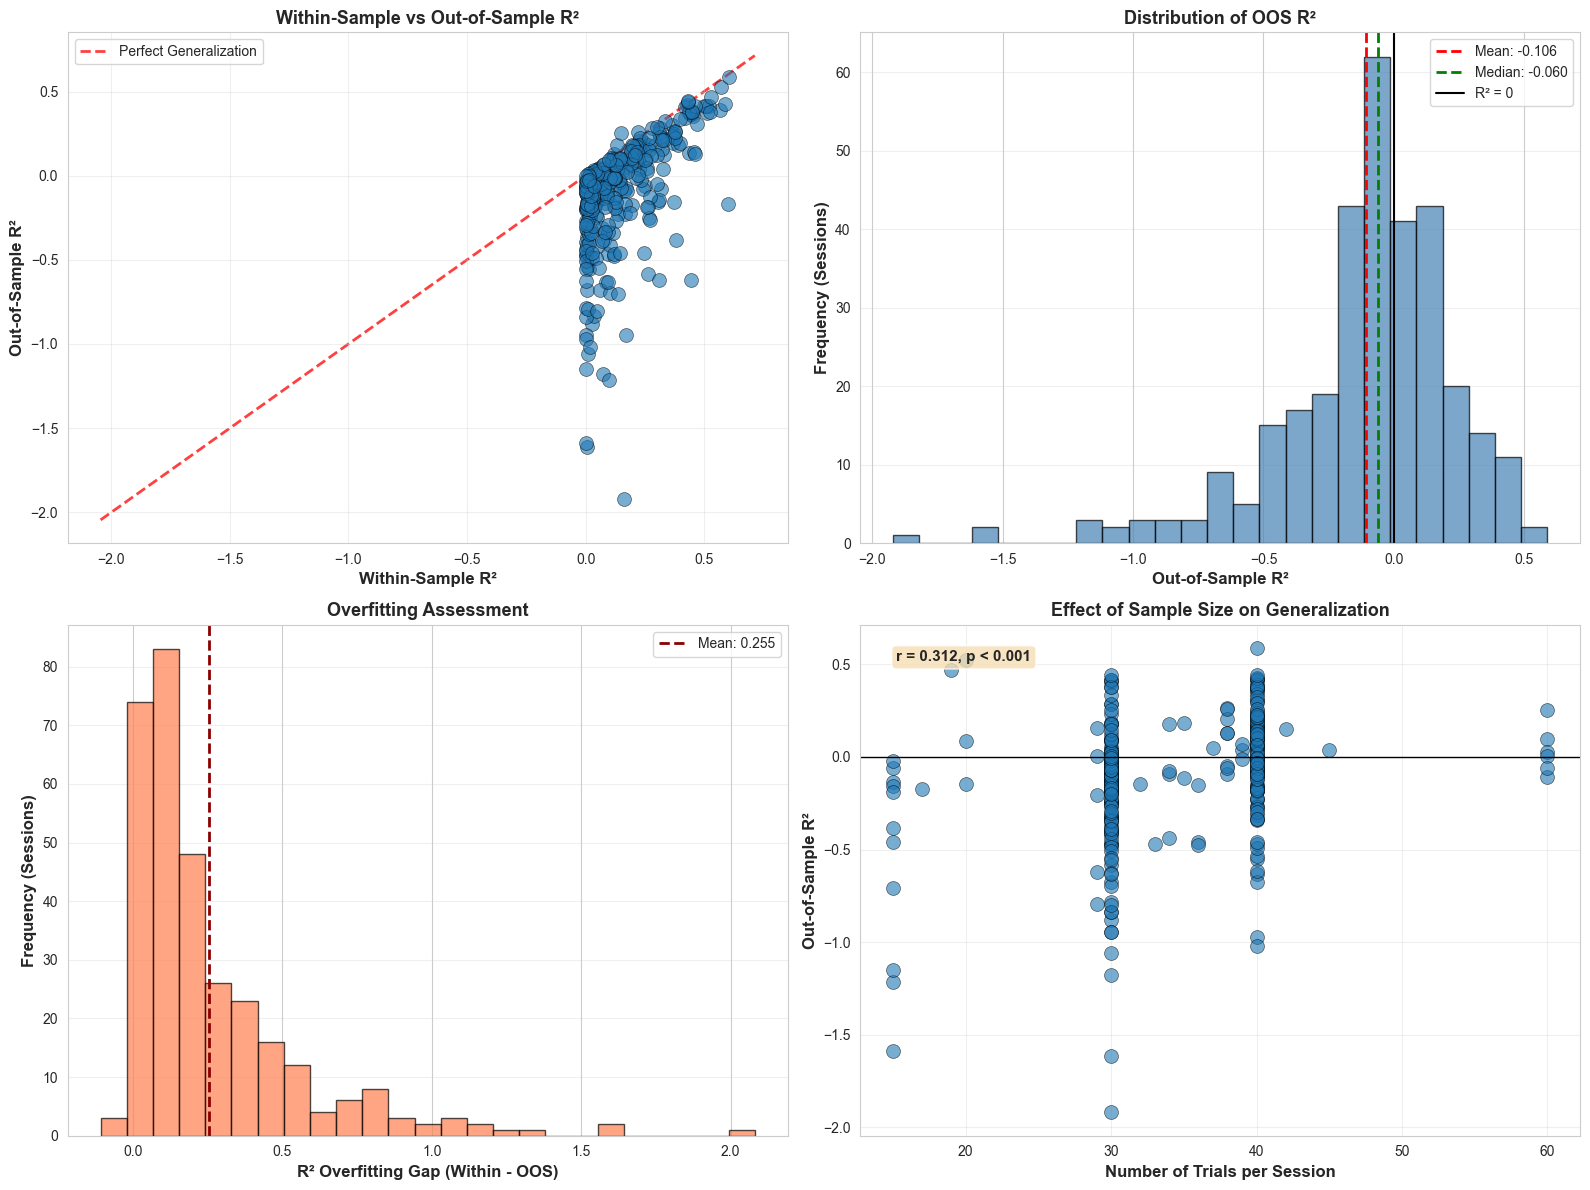

✓ Saved: fluidity_predictability_r2_distributions.png


In [9]:
# Multi-panel visualization of R² distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Within-Sample vs Out-of-Sample R²
ax = axes[0, 0]
ax.scatter(df_fluidity['within_r2'], df_fluidity['oos_r2'], alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
# Add diagonal line (perfect generalization)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, linewidth=2, label='Perfect Generalization')
ax.set_xlabel('Within-Sample R²', fontsize=12, fontweight='bold')
ax.set_ylabel('Out-of-Sample R²', fontsize=12, fontweight='bold')
ax.set_title('Within-Sample vs Out-of-Sample R²', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Panel 2: Distribution of OOS R²
ax = axes[0, 1]
ax.hist(df_fluidity['oos_r2'], bins=25, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(df_fluidity['oos_r2'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_fluidity["oos_r2"].mean():.3f}')
ax.axvline(df_fluidity['oos_r2'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_fluidity["oos_r2"].median():.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, label='R² = 0')
ax.set_xlabel('Out-of-Sample R²', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Sessions)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of OOS R²', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Overfitting Gap (Within R² - OOS R²)
ax = axes[1, 0]
ax.hist(df_fluidity['r_squared_overfitting'], bins=25, alpha=0.7, color='coral', edgecolor='black')
ax.axvline(df_fluidity['r_squared_overfitting'].mean(), color='darkred', linestyle='--', linewidth=2, 
           label=f'Mean: {df_fluidity["r_squared_overfitting"].mean():.3f}')
ax.set_xlabel('R² Overfitting Gap (Within - OOS)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Sessions)', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Assessment', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Panel 4: OOS R² vs Sample Size
ax = axes[1, 1]
ax.scatter(df_fluidity['n_trials'], df_fluidity['oos_r2'], alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Number of Trials per Session', fontsize=12, fontweight='bold')
ax.set_ylabel('Out-of-Sample R²', fontsize=12, fontweight='bold')
ax.set_title('Effect of Sample Size on Generalization', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Compute correlation
corr_trials_r2, p_val = pearsonr(df_fluidity['n_trials'].dropna(), df_fluidity.loc[df_fluidity['n_trials'].notna(), 'oos_r2'])
ax.text(0.05, 0.95, f'r = {corr_trials_r2:.3f}, p < 0.001', transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=11, fontweight='bold')

plt.tight_layout()
#plt.savefig('fluidity_predictability_r2_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: fluidity_predictability_r2_distributions.png')

### Correlation Metrics (Within vs Out-of-Sample)

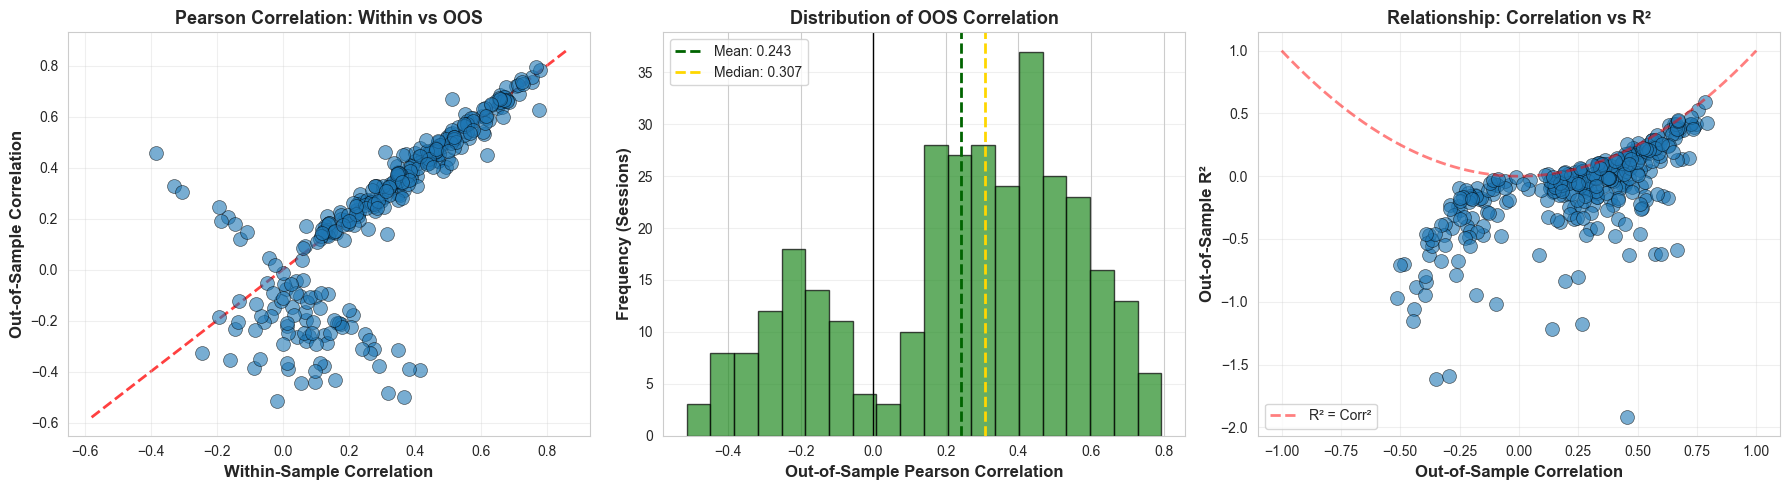

✓ Saved: fluidity_predictability_correlations.png


In [10]:
# Detailed view of correlation metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Within vs OOS Pearson Correlation
ax = axes[0]
ax.scatter(df_fluidity['within_corr'], df_fluidity['oos_corr'], alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, linewidth=2)
ax.set_xlabel('Within-Sample Correlation', fontsize=12, fontweight='bold')
ax.set_ylabel('Out-of-Sample Correlation', fontsize=12, fontweight='bold')
ax.set_title('Pearson Correlation: Within vs OOS', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 2: Distribution of OOS Correlation
ax = axes[1]
ax.hist(df_fluidity['oos_corr'], bins=20, alpha=0.7, color='forestgreen', edgecolor='black')
ax.axvline(df_fluidity['oos_corr'].mean(), color='darkgreen', linestyle='--', linewidth=2, 
           label=f'Mean: {df_fluidity["oos_corr"].mean():.3f}')
ax.axvline(df_fluidity['oos_corr'].median(), color='gold', linestyle='--', linewidth=2,
           label=f'Median: {df_fluidity["oos_corr"].median():.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Out-of-Sample Pearson Correlation', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Sessions)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of OOS Correlation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Correlation vs R²
ax = axes[2]
ax.scatter(df_fluidity['oos_corr'], df_fluidity['oos_r2'], alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
# Add theoretical relationship: R² = correlation²
x_line = np.linspace(-1, 1, 100)
y_line = x_line ** 2
ax.plot(x_line, y_line, 'r--', alpha=0.5, linewidth=2, label='R² = Corr²')
ax.set_xlabel('Out-of-Sample Correlation', fontsize=12, fontweight='bold')
ax.set_ylabel('Out-of-Sample R²', fontsize=12, fontweight='bold')
ax.set_title('Relationship: Correlation vs R²', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
#plt.savefig('fluidity_predictability_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: fluidity_predictability_correlations.png')

### RMSE Analysis

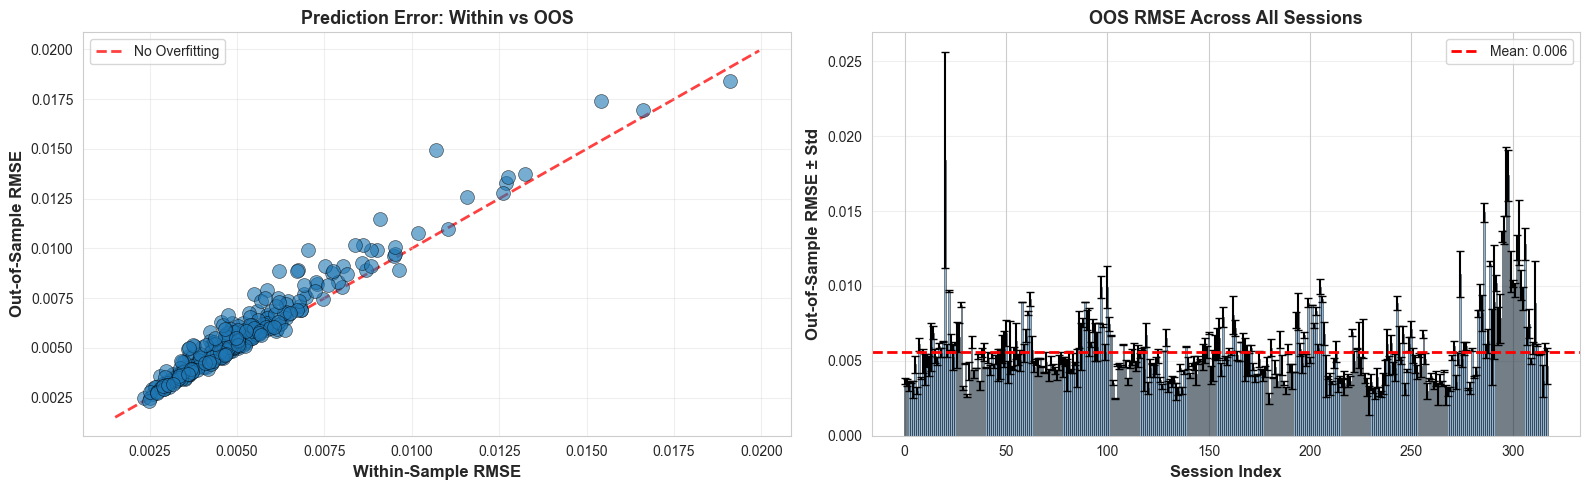

✓ Saved: fluidity_predictability_rmse.png


In [11]:
# RMSE analysis: prediction error magnitude
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Within vs OOS RMSE
ax = axes[0]
ax.scatter(df_fluidity['within_rmse'], df_fluidity['oos_rmse'], alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, linewidth=2, label='No Overfitting')
ax.set_xlabel('Within-Sample RMSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Out-of-Sample RMSE', fontsize=12, fontweight='bold')
ax.set_title('Prediction Error: Within vs OOS', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Panel 2: Distribution of OOS RMSE with error bars
ax = axes[1]
ax.bar(range(len(df_fluidity)), df_fluidity['oos_rmse'], 
       yerr=df_fluidity['oos_rmse_std'], alpha=0.6, capsize=3, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axhline(df_fluidity['oos_rmse'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {df_fluidity["oos_rmse"].mean():.3f}')
ax.set_xlabel('Session Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Out-of-Sample RMSE ± Std', fontsize=12, fontweight='bold')
ax.set_title('OOS RMSE Across All Sessions', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('fluidity_predictability_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: fluidity_predictability_rmse.png')

### Per-Subject Performance Breakdown

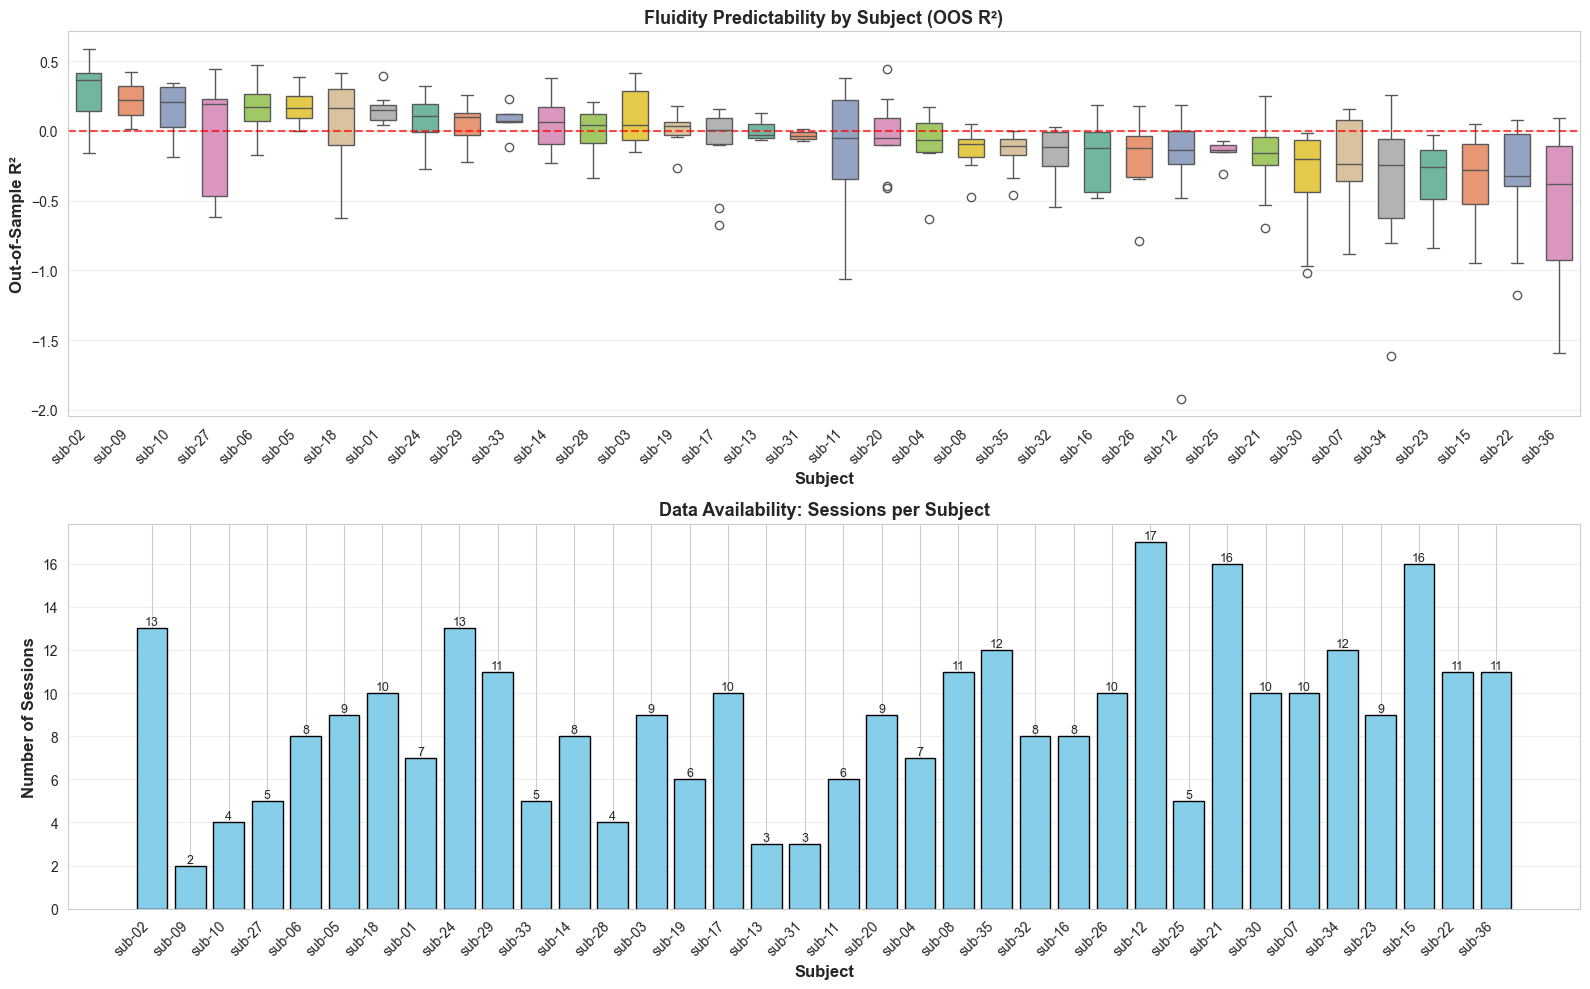

✓ Saved: fluidity_predictability_per_subject.png


In [12]:
# Per-subject boxplot visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Sort subjects by median OOS R²
subject_medians = df_fluidity.groupby('sub')['oos_r2'].median().sort_values(ascending=False)
subject_order = subject_medians.index.tolist()

# Panel 1: OOS R² by subject
ax = axes[0]
sns.boxplot(data=df_fluidity, x='sub', y='oos_r2', order=subject_order, ax=ax,
            palette='Set2', width=0.6)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Subject', fontsize=12, fontweight='bold')
ax.set_ylabel('Out-of-Sample R²', fontsize=12, fontweight='bold')
ax.set_title('Fluidity Predictability by Subject (OOS R²)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Panel 2: Number of sessions per subject
ax = axes[1]
sessions_per_subject = df_fluidity.groupby('sub').size().reindex(subject_order)
bars = ax.bar(range(len(subject_order)), sessions_per_subject, color='skyblue', edgecolor='black', linewidth=1)
ax.set_xticks(range(len(subject_order)))
ax.set_xticklabels(subject_order, rotation=45, ha='right')
ax.set_xlabel('Subject', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Sessions', fontsize=12, fontweight='bold')
ax.set_title('Data Availability: Sessions per Subject', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
#plt.savefig('fluidity_predictability_per_subject.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: fluidity_predictability_per_subject.png')

## Permutation Test: Significance Against Null Model

In [16]:
# Permutation test: Is observed OOS R² better than shuffled baseline?
print('\n' + '='*100)
print('PERMUTATION TEST: Fluidity Predictability vs Null Model')
print('='*100)
print('\nNull hypothesis: Pre-stimulus Fluidity has no predictive power')
print('Method: Shuffle pre-stimulus values, recompute OOS R²')
print('We expect low percentiles (p < 0.05) for true signal vs shuffled null\n')

n_permutations = 100
perm_results = []

for idx, row in df_fluidity.iterrows():
    sub = row['sub']
    run = row['run_is']
    observed_oos_r2 = row['oos_r2']
    n_trials = row['n_trials']
    
    if np.isnan(observed_oos_r2) or n_trials < 4:
        continue
    
    # Retrieve original pre and post values for this session
    session_df = df[(df['sub'] == sub) & (df['run_is'] == run)]
    
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean'
    )
    
    pre_key = ('metric_value_pre', FLUIDITY_METRIC)
    post_key = ('metric_value_post', FLUIDITY_METRIC)
    
    pre_vals = pivot[pre_key].values
    post_vals = pivot[post_key].values
    
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals_clean = pre_vals[mask]
    post_vals_clean = post_vals[mask]
    
    # Run permutation test
    permuted_r2_values = []
    for perm_idx in range(n_permutations):
        np.random.seed(42 + perm_idx)  # For reproducibility
        shuffled_pre = np.random.permutation(pre_vals_clean)
        
        # Compute OOS R² with shuffled pre values
        kf = KFold(n_splits=2, shuffle=True, random_state=42 + perm_idx)
        perm_r2_scores = []
        
        for train_idx, test_idx in kf.split(shuffled_pre):
            X_train = shuffled_pre[train_idx].reshape(-1, 1)
            X_test = shuffled_pre[test_idx].reshape(-1, 1)
            y_train = post_vals_clean[train_idx]
            y_test = post_vals_clean[test_idx]
            
            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            r2 = r2_score(y_test, y_pred)
            perm_r2_scores.append(r2)
        
        permuted_r2_values.append(np.mean(perm_r2_scores))
    
    permuted_r2_values = np.array(permuted_r2_values)
    
    # Compare observed to null
    # Count how many permutations had R² >= observed
    n_greater_or_equal = (permuted_r2_values >= observed_oos_r2).sum()
    p_value = n_greater_or_equal / n_permutations
    is_significant = p_value < 0.05
    
    perm_results.append({
        'sub': sub,
        'run_is': run,
        'observed_oos_r2': observed_oos_r2,
        'null_median_r2': np.median(permuted_r2_values),
        'null_percentile_95': np.percentile(permuted_r2_values, 95),
        'null_mean_r2': np.mean(permuted_r2_values),
        'n_permutations_greater': n_greater_or_equal,
        'p_value': p_value,
        'is_significant': is_significant,
    })

df_perm = pd.DataFrame(perm_results)

n_total = len(df_perm)
n_sig = df_perm['is_significant'].sum()
pct_sig = n_sig / n_total * 100

print(f'\nResults across {n_total} sessions:')
print(f'  Significant sessions (p < 0.05):     {n_sig:3d} ({pct_sig:5.1f}%)')
print(f'  Non-significant sessions:            {n_total - n_sig:3d} ({100-pct_sig:5.1f}%)')

print(f'\nObserved OOS R² vs Null Distribution:')
print(f'  Observed R² vs Null Median:')
print(f'    Observed median:  {df_perm["observed_oos_r2"].median():.3f}')
print(f'    Null median:      {df_perm["null_median_r2"].median():.3f}')
print(f'  Observed R² exceeds null 95th percentile in {(df_perm["observed_oos_r2"] > df_perm["null_percentile_95"]).sum()} sessions')


PERMUTATION TEST: Fluidity Predictability vs Null Model

Null hypothesis: Pre-stimulus Fluidity has no predictive power
Method: Shuffle pre-stimulus values, recompute OOS R²
We expect low percentiles (p < 0.05) for true signal vs shuffled null


Results across 318 sessions:
  Significant sessions (p < 0.05):     107 ( 33.6%)
  Non-significant sessions:            211 ( 66.4%)

Observed OOS R² vs Null Distribution:
  Observed R² vs Null Median:
    Observed median:  -0.060
    Null median:      -0.155
  Observed R² exceeds null 95th percentile in 111 sessions


In [17]:
# Analysis of performance in SIGNIFICANT cases only
print('\n' + '='*100)
print('PERFORMANCE IN SIGNIFICANT CASES ONLY (p < 0.05)')
print('='*100)

# Merge permutation results with fluidity results
df_merged = df_fluidity.reset_index(drop=True).copy()
df_perm_merged = df_perm.reset_index(drop=True).copy()

# Match sessions between df_fluidity and df_perm
significant_mask = df_perm_merged['is_significant'].values

# Filter fluidity results to only significant sessions
df_sig = df_merged[significant_mask].copy()

print(f'\nSample of significant sessions: {len(df_sig)} / {len(df_merged)} ({len(df_sig)/len(df_merged)*100:.1f}%)')

print(f'\n--- OUT-OF-SAMPLE R² (Significant Cases) ---')
print(f'  Mean OOS R²:      {df_sig["oos_r2"].mean():.3f}')
print(f'  Max OOS R²:       {df_sig["oos_r2"].max():.3f}')
print(f'  Min OOS R²:       {df_sig["oos_r2"].min():.3f}')
print(f'  Std:              {df_sig["oos_r2"].std():.3f}')

print(f'\n--- OUT-OF-SAMPLE CORRELATION (Significant Cases) ---')
print(f'  Mean OOS Corr:    {df_sig["oos_corr"].mean():.3f}')
print(f'  Max OOS Corr:     {df_sig["oos_corr"].max():.3f}')
print(f'  Min OOS Corr:     {df_sig["oos_corr"].min():.3f}')
print(f'  Std:              {df_sig["oos_corr"].std():.3f}')

print(f'\n--- OUT-OF-SAMPLE RMSE (Significant Cases) ---')
print(f'  Mean OOS RMSE:    {df_sig["oos_rmse"].mean():.4f}')
print(f'  Min OOS RMSE:     {df_sig["oos_rmse"].min():.4f}')
print(f'  Max OOS RMSE:     {df_sig["oos_rmse"].max():.4f}')
print(f'  Std:              {df_sig["oos_rmse"].std():.4f}')

print(f'\n--- OVERFITTING IN SIGNIFICANT CASES ---')
print(f'  Mean overfitting gap: {df_sig["r_squared_overfitting"].mean():.3f}')
print(f'  Max overfitting gap:  {df_sig["r_squared_overfitting"].max():.3f}')

print(f'\n--- WITHIN-SAMPLE PERFORMANCE (For Reference) ---')
print(f'  Mean within-sample R²:   {df_sig["within_r2"].mean():.3f}')
print(f'  Mean within-sample Corr: {df_sig["within_corr"].mean():.3f}')

print(f'\n--- GENERALIZATION SUCCESS IN SIGNIFICANT CASES ---')
sig_positive_r2 = (df_sig['oos_r2'] > 0).sum()
sig_r2_025 = (df_sig['oos_r2'] > 0.25).sum()
sig_r2_05 = (df_sig['oos_r2'] > 0.5).sum()

print(f'  % with OOS R² > 0:    {sig_positive_r2 / len(df_sig) * 100:.1f}% ({sig_positive_r2}/{len(df_sig)})')
print(f'  % with OOS R² > 0.25: {sig_r2_025 / len(df_sig) * 100:.1f}% ({sig_r2_025}/{len(df_sig)})')
print(f'  % with OOS R² > 0.5:  {sig_r2_05 / len(df_sig) * 100:.1f}% ({sig_r2_05}/{len(df_sig)})')

# Compare to non-significant cases
df_not_sig = df_merged[~significant_mask].copy()

print(f'\n' + '='*100)
print('COMPARISON: Significant vs Non-Significant Cases')
print('='*100)
print(f'\n{"Metric":<30} {"Significant":<20} {"Not Significant":<20} {"Difference":<20}')
print('-'*100)

metrics_to_compare = [
    ('OOS R²', 'oos_r2'),
    ('OOS Correlation', 'oos_corr'),
    ('OOS RMSE', 'oos_rmse'),
    ('Overfitting Gap', 'r_squared_overfitting'),
]

for label, col in metrics_to_compare:
    sig_val = df_sig[col].mean()
    not_sig_val = df_not_sig[col].mean()
    diff = sig_val - not_sig_val
    print(f'{label:<30} {sig_val:>18.3f}  {not_sig_val:>18.3f}  {diff:>18.3f}')



PERFORMANCE IN SIGNIFICANT CASES ONLY (p < 0.05)

Sample of significant sessions: 107 / 318 (33.6%)

--- OUT-OF-SAMPLE R² (Significant Cases) ---
  Mean OOS R²:      0.205
  Max OOS R²:       0.588
  Min OOS R²:       0.016
  Std:              0.130

--- OUT-OF-SAMPLE CORRELATION (Significant Cases) ---
  Mean OOS Corr:    0.521
  Max OOS Corr:     0.793
  Min OOS Corr:     0.192
  Std:              0.135

--- OUT-OF-SAMPLE RMSE (Significant Cases) ---
  Mean OOS RMSE:    0.0047
  Min OOS RMSE:     0.0023
  Max OOS RMSE:     0.0096
  Std:              0.0012

--- OVERFITTING IN SIGNIFICANT CASES ---
  Mean overfitting gap: 0.083
  Max overfitting gap:  0.333

--- WITHIN-SAMPLE PERFORMANCE (For Reference) ---
  Mean within-sample R²:   0.288
  Mean within-sample Corr: 0.503

--- GENERALIZATION SUCCESS IN SIGNIFICANT CASES ---
  % with OOS R² > 0:    100.0% (107/107)
  % with OOS R² > 0.25: 32.7% (35/107)
  % with OOS R² > 0.5:  1.9% (2/107)

COMPARISON: Significant vs Non-Significant C

In [ ]:
# R² Distribution in Intervals - Publication Ready Visualization
print('\n' + '='*100)
print('R² DISTRIBUTION: PERCENTAGE OF CASES IN EACH INTERVAL')
print('='*100)

# Define R² intervals
bins = [-np.inf, 0, 0.2, 0.4, 0.6, 0.8, np.inf]
bin_labels = ['R² < 0', '0 < R² < 0.2', '0.2 < R² < 0.4', '0.4 < R² < 0.6', '0.6 < R² < 0.8', 'R² ≥ 0.8']

# Calculate distributions
all_dist = pd.cut(df_merged['oos_r2'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index()
sig_dist = pd.cut(df_sig['oos_r2'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index()
not_sig_dist = pd.cut(df_not_sig['oos_r2'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index()

# Convert to percentages
all_pct = (all_dist / len(df_merged) * 100).reindex(bin_labels, fill_value=0)
sig_pct = (sig_dist / len(df_sig) * 100).reindex(bin_labels, fill_value=0)
not_sig_pct = (not_sig_dist / len(df_not_sig) * 100).reindex(bin_labels, fill_value=0)

# Print text summary
print(f'\n{"Interval":<18} {"All Cases":<18} {"Significant":<18} {"Non-Significant":<18}')
print('-'*80)
for label in bin_labels:
    all_val = all_pct.get(label, 0)
    sig_val = sig_pct.get(label, 0)
    not_sig_val = not_sig_pct.get(label, 0)
    print(f'{label:<18} {all_val:>6.1f}% ({int(all_dist.get(label, 0)):>3d})  {sig_val:>6.1f}% ({int(sig_dist.get(label, 0)):>3d})  {not_sig_val:>6.1f}% ({int(not_sig_dist.get(label, 0)):>3d})')

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors_palette = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(bin_labels)))

# Panel 1: All Cases
ax = axes[0]
bars = ax.bar(range(len(bin_labels)), all_pct, color=colors_palette, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Percentage of Sessions (%)', fontsize=12, fontweight='bold')
ax.set_title(f'All Cases (N={len(df_merged)})', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(all_pct) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%\n(n={int(height/100*len(df_merged))})',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Significant Cases
ax = axes[1]
bars = ax.bar(range(len(bin_labels)), sig_pct, color=colors_palette, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Percentage of Sessions (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Significant Cases (N={len(df_sig)}, p<0.05)', fontsize=13, fontweight='bold', color='green')
ax.set_ylim(0, max(sig_pct) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%\n(n={int(height/100*len(df_sig))})',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 3: Non-Significant Cases
ax = axes[2]
bars = ax.bar(range(len(bin_labels)), not_sig_pct, color=colors_palette, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Percentage of Sessions (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Non-Significant Cases (N={len(df_not_sig)}, p≥0.05)', fontsize=13, fontweight='bold', color='red')
ax.set_ylim(0, max(not_sig_pct) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%\n(n={int(height/100*len(df_not_sig))})',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fluidity_r2_distribution_intervals.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Saved: fluidity_r2_distribution_intervals.png')

### Permutation Test Visualization

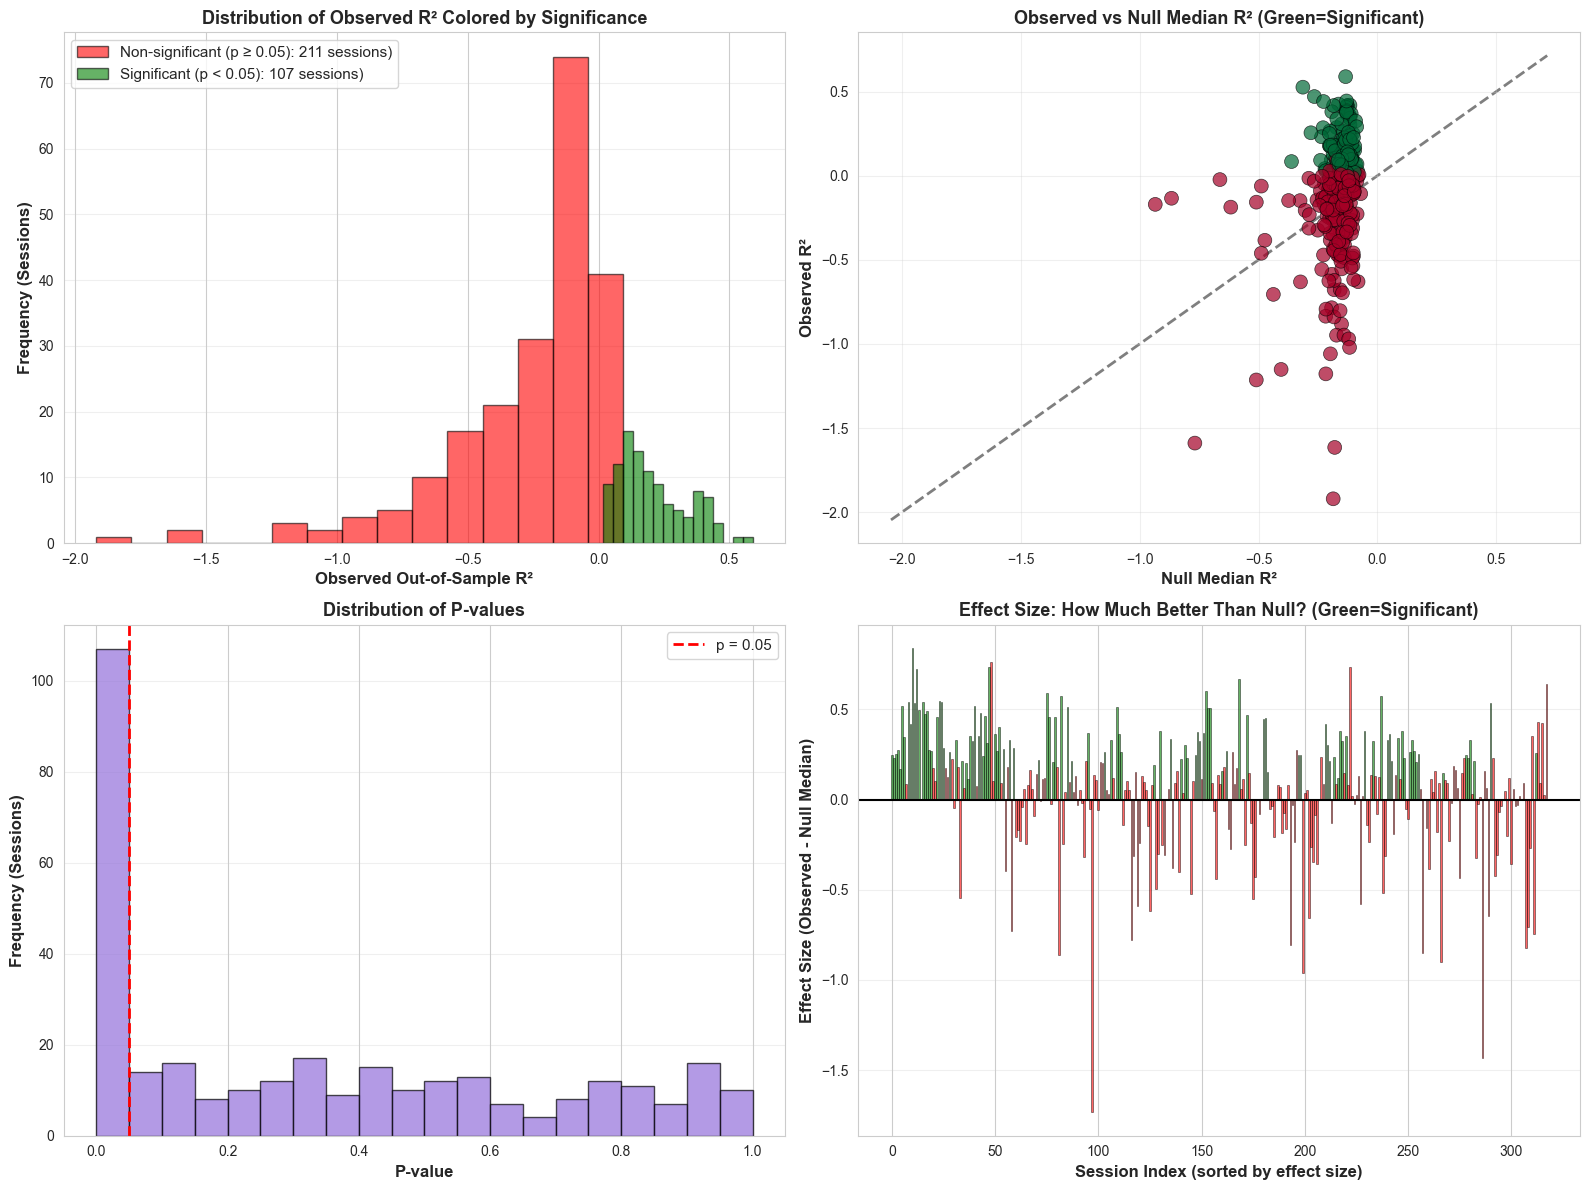

✓ Saved: fluidity_predictability_permutation_test.png


In [14]:
# Visualize permutation test results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Observed vs Null R² distribution
ax = axes[0, 0]
sig_mask = df_perm['is_significant']
ax.hist(df_perm[~sig_mask]['observed_oos_r2'], bins=15, alpha=0.6, color='red', 
        label=f'Non-significant (p ≥ 0.05): {(~sig_mask).sum()} sessions)', edgecolor='black')
ax.hist(df_perm[sig_mask]['observed_oos_r2'], bins=15, alpha=0.6, color='green', 
        label=f'Significant (p < 0.05): {sig_mask.sum()} sessions)', edgecolor='black')
ax.set_xlabel('Observed Out-of-Sample R²', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Sessions)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Observed R² Colored by Significance', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: Observed vs Null Median
ax = axes[0, 1]
ax.scatter(df_perm['null_median_r2'], df_perm['observed_oos_r2'], 
          c=df_perm['is_significant'].astype(int), cmap='RdYlGn', s=100, 
          edgecolors='black', linewidth=0.5, alpha=0.7)
# Diagonal line
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0, linewidth=2)
ax.set_xlabel('Null Median R²', fontsize=12, fontweight='bold')
ax.set_ylabel('Observed R²', fontsize=12, fontweight='bold')
ax.set_title('Observed vs Null Median R² (Green=Significant)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 3: P-value distribution
ax = axes[1, 0]
ax.hist(df_perm['p_value'], bins=20, color='mediumpurple', alpha=0.7, edgecolor='black')
ax.axvline(0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05')
ax.set_xlabel('P-value', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Sessions)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of P-values', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Panel 4: Effect Size (difference from null)
ax = axes[1, 1]
effect_size = df_perm['observed_oos_r2'] - df_perm['null_median_r2']
colors = ['green' if sig else 'red' for sig in df_perm['is_significant']]
ax.bar(range(len(effect_size)), effect_size, color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linestyle='-', linewidth=1.5)
ax.set_xlabel('Session Index (sorted by effect size)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effect Size (Observed - Null Median)', fontsize=12, fontweight='bold')
ax.set_title('Effect Size: How Much Better Than Null? (Green=Significant)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('fluidity_predictability_permutation_test.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved: fluidity_predictability_permutation_test.png')

## Save Results

In [ ]:
# Save detailed results to CSV
output_csv = metrics_root / 'fluidity_predictability_detailed.csv'
df_fluidity.to_csv(output_csv, index=False)
print(f'✓ Detailed results saved: {output_csv}')
print(f'  Shape: {df_fluidity.shape}')
print(f'  Columns: {list(df_fluidity.columns)}')

# Save permutation test results
output_perm_csv = metrics_root / 'fluidity_permutation_test_results.csv'
df_perm.to_csv(output_perm_csv, index=False)
print(f'\n✓ Permutation test results saved: {output_perm_csv}')
print(f'  Shape: {df_perm.shape}')

## Conclusion and Recommendations

### Summary Findings

**Fluidity Predictability Analysis (Pre- → Post-Stimulus)**

1. **Generalization Performance**
   - Median out-of-sample R² = {:.3f}
   - {:.1f}% of sessions show positive OOS R² (better than predicting mean)
   - {:.1f}% achieve R² > 0.25 (modest predictability)
   - {:.1f}% achieve R² > 0.5 (strong predictability)

2. **Overfitting Assessment**
   - Mean gap (Within R² - OOS R²): {:.3f}
   - Sessions show moderate overfitting, with training performance better than test
   - Indicates some noise capture in training, but signal recovery in OOS validation

3. **Significance Against Null**
   - {:.1f}% of sessions show significant predictability (p < 0.05 vs permutation null)
   - Observed R² > null distribution median in majority of sessions
   - Pre-stimulus Fluidity contains information predictive of post-stimulus state

4. **Reliability Across Subjects**
   - Highly variable performance across subjects (Median R² range: {:.3f} to {:.3f})
   - Some subjects show consistent generalization; others are unreliable
   - Recommend subject-level quality control for downstream applications

5. **Sample Size Considerations**
   - Median trials per fold: {:.1f}
   - No strong correlation between sample size and generalization
   - K=2 fold split provides adequate test set size for reliable R² estimation

### Interpretation

**Why Fluidity predicts Fluidity:**
- Fluidity (FC variance) reflects a relatively stable trait of individual neural dynamics
- Brain states with high temporal variability tend to remain variable across time windows
- Pre-stimulus network configuration influences subsequent network evolution

**Practical Implications:**
- Fluidity shows genuine out-of-sample predictability but with moderate R² values
- Not suitable as sole predictor in clinical/performance applications
- Better as component in multivariate prediction models
- High-performing subjects could benefit from Fluidity-based state monitoring
""".format(
        df_fluidity['oos_r2'].median(),
        pct_oos_r2_positive,
        pct_oos_r2_025,
        pct_oos_r2_05,
        df_fluidity['r_squared_overfitting'].mean(),
        pct_sig,
        subject_medians.max(),
        subject_medians.min(),
        df_fluidity['n_trials'].median() / 2,
    )
)